# EN3160 Assignment 1 on Intensity Transformations and Neighborhood Filtering

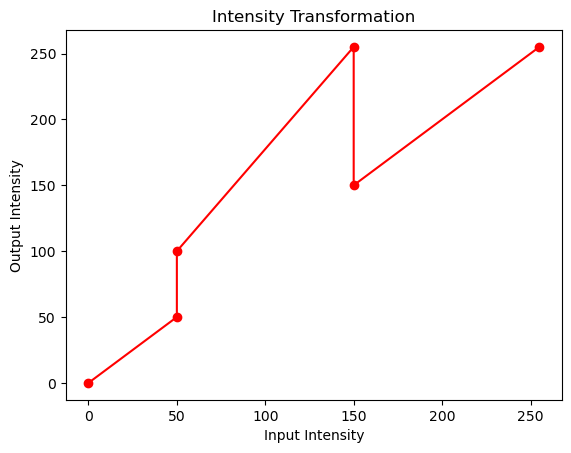

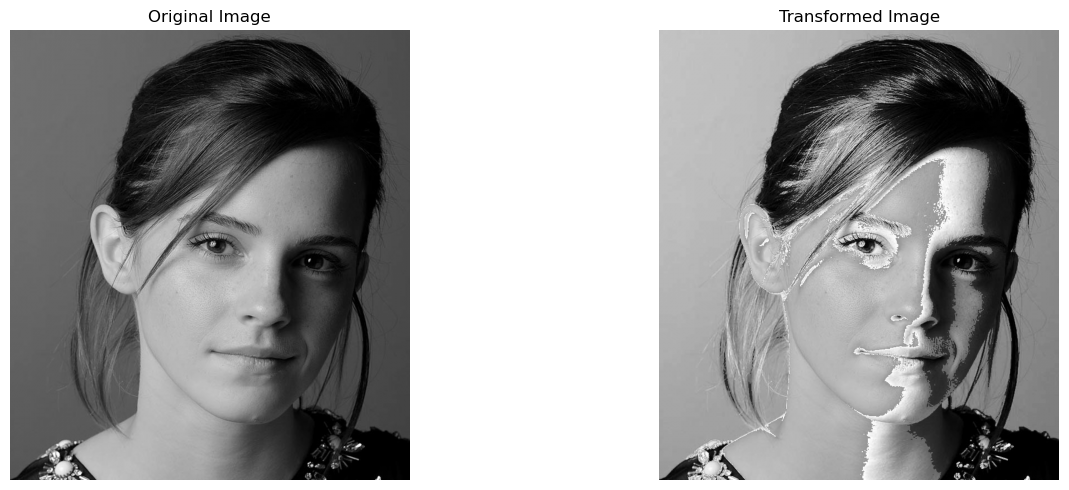

In [90]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math


def intensity_transform(im, breakpoints):

    x = breakpoints[:, 0]
    y = breakpoints[:, 1]

    lut = np.interp(np.arange(256), x, y)
    lut = np.clip(lut, 0, 255).astype(np.uint8)

    transformed_im = lut[im]
    
    return transformed_im

eps = 1e-5
breakpoints = np.array([
    [0,0],
    [50,50],
    [50+eps,100],
    [150,255],
    [150+eps,150],
    [255,255],
])

im1 = cv2.imread('Images/emma.jpg', cv2.IMREAD_GRAYSCALE)
assert im1 is not None

intensity_transformed_im1 = intensity_transform(im1, breakpoints)

plt.plot(breakpoints[:, 0], breakpoints[:, 1], 'ro-')
plt.xlabel('Input Intensity')
plt.ylabel('Output Intensity')
plt.title('Intensity Transformation')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].imshow(im1, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(intensity_transformed_im1, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Transformed Image")
axes[1].axis("off")

plt.tight_layout()
plt.show()

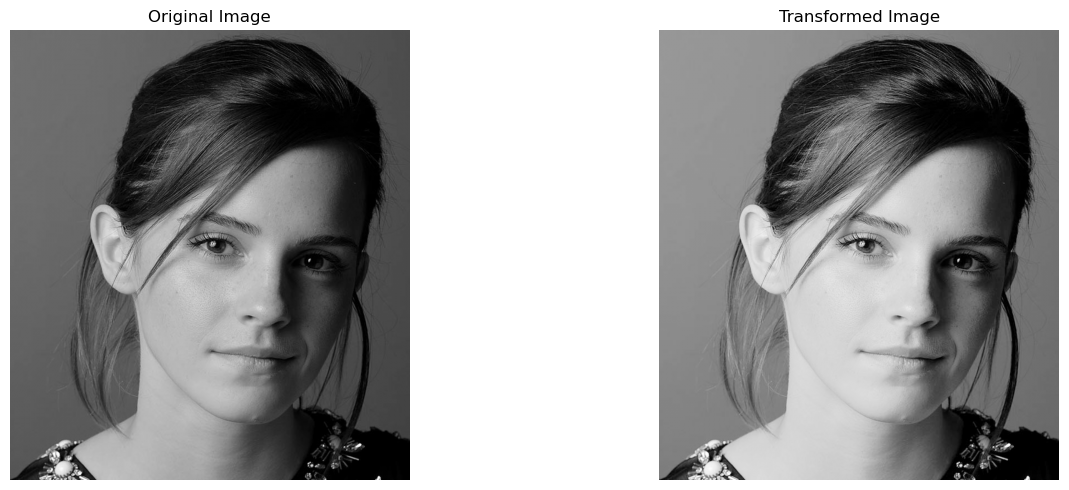

In [2]:
breakpoints_new = np.array([
    [0, 0],
    [60, 100],
    [160, 200],
    [255, 255]
])

intensity_transformed_im1 = intensity_transform(im1, breakpoints_new)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].imshow(im1, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(intensity_transformed_im1, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Transformed Image")
axes[1].axis("off")

plt.tight_layout()
plt.show()

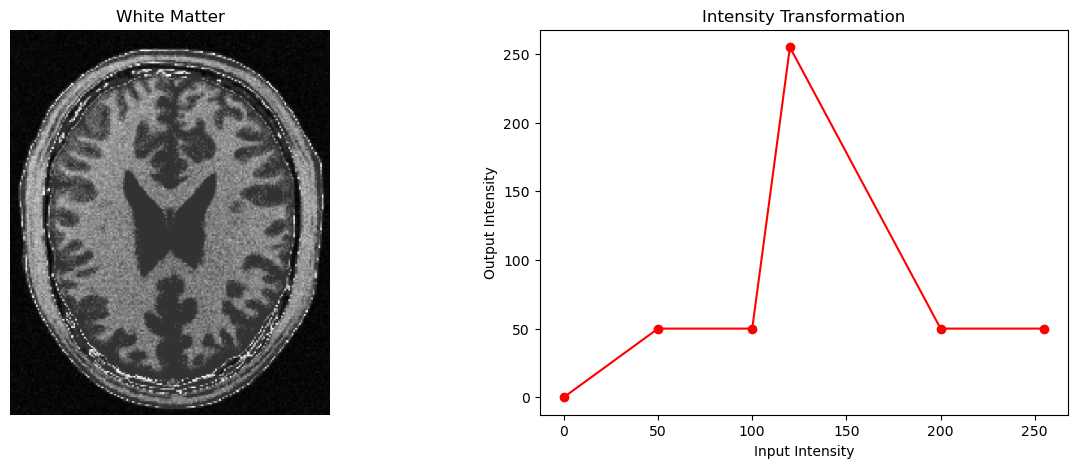

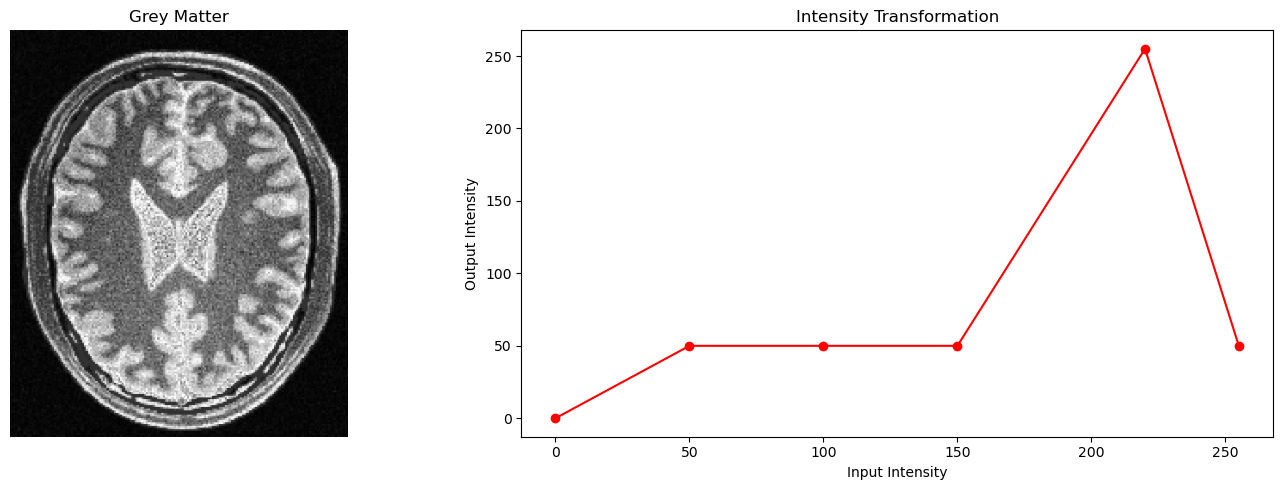

In [3]:
im2 = cv2.imread('Images/brain.png', cv2.IMREAD_GRAYSCALE)
assert im2 is not None

breakpoints_white = np.array([
    [0, 0],
    [50, 50],
    [100, 50],
    [120, 255],
    [200, 50],
    [255, 50],
])

breakpoints_grey = np.array([
    [0, 0],
    [50, 50],
    [100, 50],
    [150, 50],
    [220, 255],
    [255, 50],
])

white_matter = intensity_transform(im2, breakpoints_white)
grey_matter = intensity_transform(im2, breakpoints_grey)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].imshow(white_matter, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("White Matter")
axes[0].axis("off")

axes[1].plot(breakpoints_white[:, 0], breakpoints_white[:, 1], 'ro-')
axes[1].set_xlabel('Input Intensity')
axes[1].set_ylabel('Output Intensity')
axes[1].set_title('Intensity Transformation')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].imshow(grey_matter, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Grey Matter")
axes[0].axis("off")

axes[1].plot(breakpoints_grey[:, 0], breakpoints_grey[:, 1], 'ro-')
axes[1].set_xlabel('Input Intensity')
axes[1].set_ylabel('Output Intensity')
axes[1].set_title('Intensity Transformation')
plt.tight_layout()
plt.show()

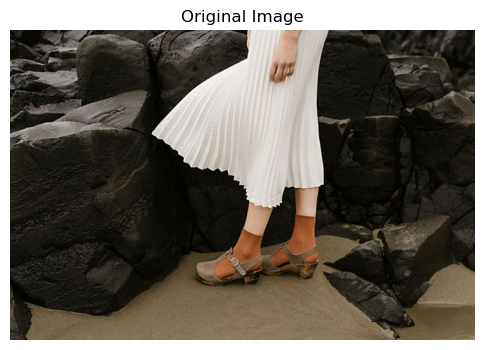

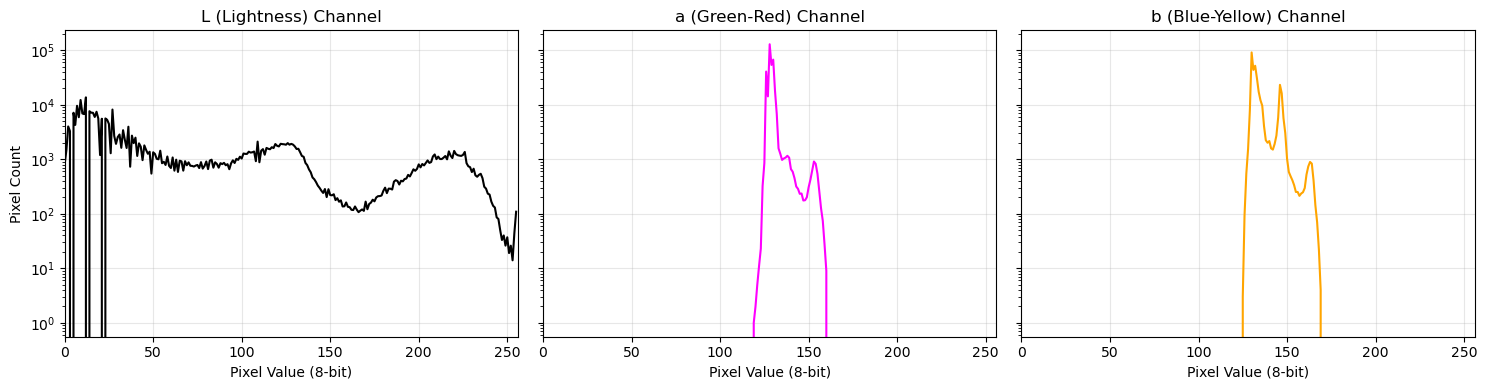

In [4]:
im3 = cv2.imread('Images/feet.jpeg')
im3_rgb = cv2.cvtColor(im3, cv2.COLOR_BGR2RGB)
assert im3 is not None

plt.figure(figsize=(6, 5))
plt.imshow(im3_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

im3_lab = cv2.cvtColor(im3, cv2.COLOR_BGR2LAB)
l_channel_im3 = im3_lab[:, :, 0]

channels = ("L (Lightness)", "a (Green-Red)", "b (Blue-Yellow)")
colors = ("black", "magenta", "orange")

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for idx, (ax, name, color) in enumerate(zip(axes, channels, colors)):
    hist = cv2.calcHist([im3_lab], [idx], None, [256], [0, 256])

    ax.plot(hist, color=color, lw=1.5)
    ax.set_title(f"{name} Channel")
    ax.set_xlim([0, 256])
    ax.set_yscale("log") 
    ax.set_xlabel("Pixel Value (8-bit)")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Pixel Count")
plt.tight_layout()
plt.show()



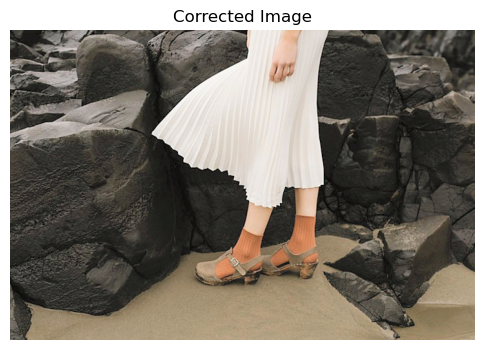

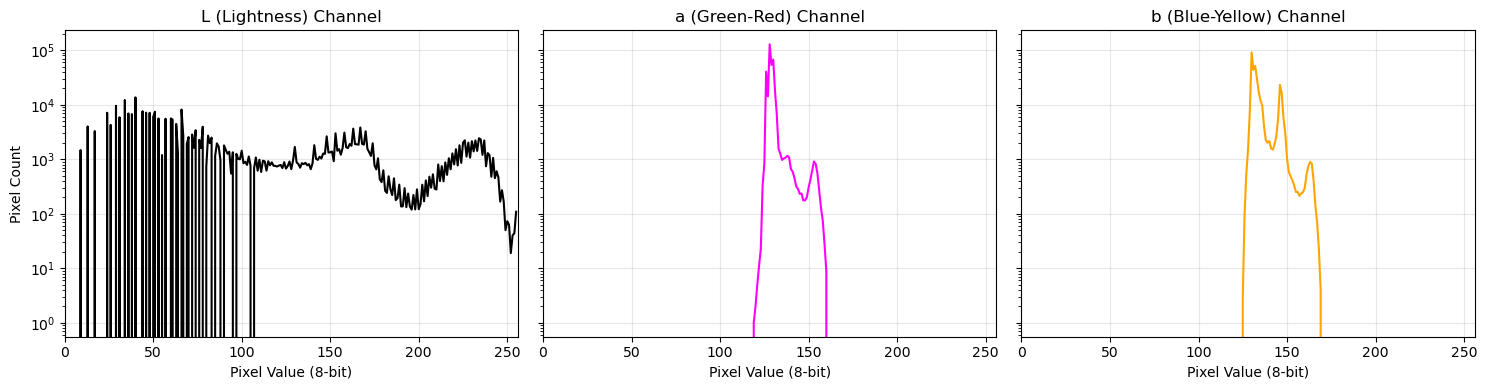

In [5]:
def gamma_correction(image, gamma):
    return np.clip(255 * (image / 255) ** gamma, 0, 255).astype(np.uint8)

l_channel_im3_corrected = gamma_correction(l_channel_im3, 0.6)
im3_lab_corrected = im3_lab.copy()
im3_lab_corrected[:, :, 0] = l_channel_im3_corrected
im3_corrected = cv2.cvtColor(im3_lab_corrected, cv2.COLOR_LAB2RGB)

channels = ("L (Lightness)", "a (Green-Red)", "b (Blue-Yellow)")
colors = ("black", "magenta", "orange")

plt.figure(figsize=(6, 5))
plt.imshow(im3_corrected)
plt.title("Corrected Image")
plt.axis("off")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for idx, (ax, name, color) in enumerate(zip(axes, channels, colors)):
    hist = cv2.calcHist([im3_lab_corrected], [idx], None, [256], [0, 256])

    ax.plot(hist, color=color, lw=1.5)
    ax.set_title(f"{name} Channel")
    ax.set_xlim([0, 256])
    ax.set_yscale("log") 
    ax.set_xlabel("Pixel Value (8-bit)")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Pixel Count")
plt.tight_layout()
plt.show()


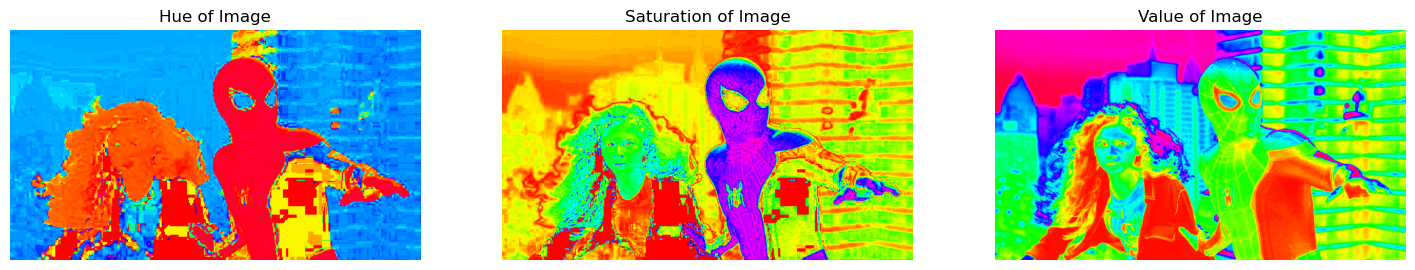

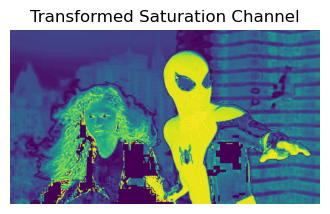

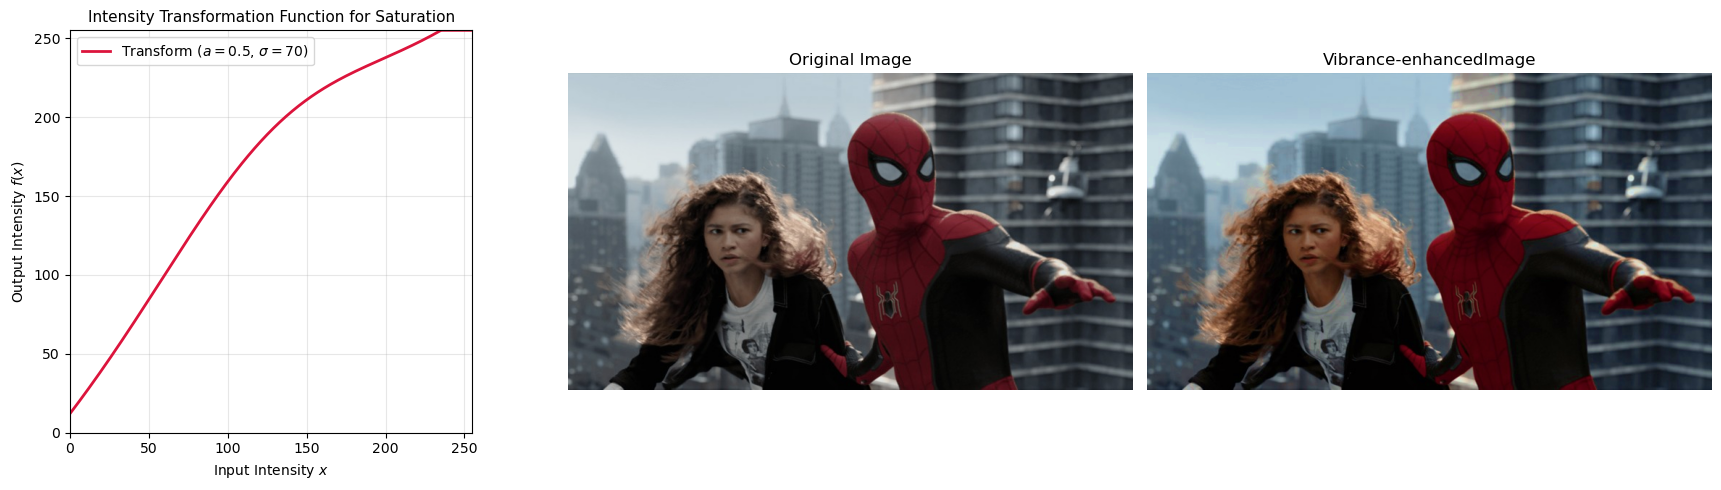

In [9]:
im4 = cv2.imread("Images/spiderman.jpeg")
assert im4 is not None

im4_rgb = cv2.cvtColor(im4, cv2.COLOR_BGR2RGB)
im4_hsv = cv2.cvtColor(im4, cv2.COLOR_BGR2HSV)

def f_transform(image, a, sigma=70):
    return np.clip(
        image + 128.0 * a * np.exp(-((image - 128.0) ** 2) / (2 * sigma**2)), 0, 255
    ).astype(np.uint8)


im4_saturation = im4_hsv[:, :, 1]

im4_saturation_transform = f_transform(im4_saturation, a=0.6, sigma=70)

x = np.arange(256, dtype=np.float32)
a = 0.5
sigma = 70
fx = np.minimum(
    x + a * 128.0 * np.exp(-((x - 128.0) ** 2) / (2.0 * sigma**2)), 255.0
)

im4_corrected = im4_hsv.copy()
im4_corrected[:, :, 1] = im4_saturation_transform
im4_corrected = cv2.cvtColor(im4_corrected, cv2.COLOR_HSV2RGB)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(im4_hsv[:,:,0], cmap="hsv")
axes[0].set_title("Hue of Image")
axes[0].axis("off")

axes[1].imshow(im4_hsv[:,:,1], cmap="hsv")
axes[1].set_title("Saturation of Image")
axes[1].axis("off")


axes[2].imshow(im4_hsv[:,:,2], cmap="hsv")
axes[2].set_title("Value of Image")
axes[2].axis("off")


plt.figure(figsize=(4, 5))
plt.imshow(im4_saturation_transform)
plt.title("Transformed Saturation Channel")
plt.axis("off")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[1].imshow(im4_rgb)
axes[1].set_title("Original Image")
axes[1].axis("off")

axes[0].plot(x, fx, color="crimson", lw=2, label=f"Transform ($a={a}$, $\sigma={int(sigma)}$)")
axes[0].set_title("Intensity Transformation Function for Saturation", fontsize=11)
axes[0].set_xlabel("Input Intensity $x$", fontsize=10)
axes[0].set_ylabel("Output Intensity $f(x)$", fontsize=10)
axes[0].set_xlim([0, 255])
axes[0].set_ylim([0, 255])
axes[0].grid(alpha=0.3)
axes[0].legend(loc="upper left")
axes[0].set_aspect("equal", adjustable="box")

axes[2].imshow(im4_corrected)
axes[2].set_title("Vibrance-enhancedImage")
axes[2].axis("off")

plt.tight_layout()
plt.show()

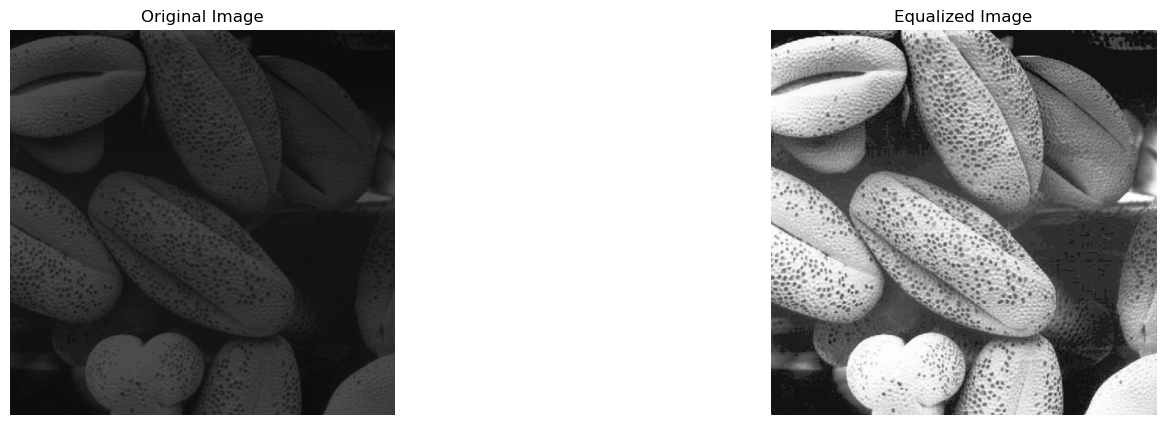

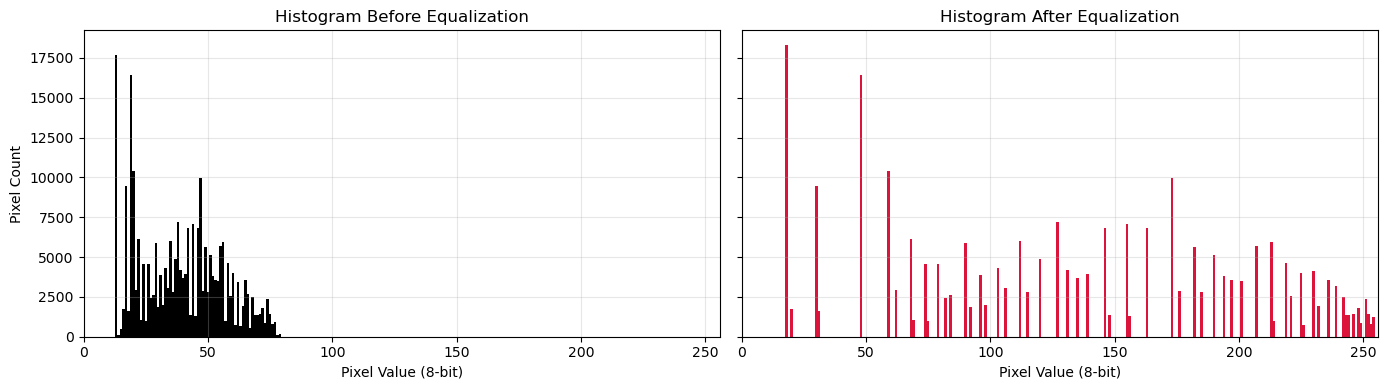

In [22]:
im5 = cv2.imread("Images/shells.tif", cv2.IMREAD_GRAYSCALE)

def hist_equal(image):
    L = 256
    M, N = image.shape

    hist = cv2.calcHist([image], [0], None, [L], [0, L])

    cdf = np.cumsum(hist)

    transform_map = np.array([(L-1)/(M*N)*cdf[k] for k in range (256)]).astype("uint8")
    equalized_image = transform_map[image]

    return equalized_image

im5_equalized = hist_equal(im5)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].imshow(im5, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(im5_equalized, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Equalized Image")
axes[1].axis("off")

hist_orig = cv2.calcHist([im5], [0], None, [256], [0, 256])
hist_eq = cv2.calcHist([im5_equalized], [0], None, [256], [0, 256])
bins = np.arange(256)
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

axes[0].bar(bins, hist_orig, width=1.0, color="black", edgecolor="none")
axes[0].set_title("Histogram Before Equalization")
axes[0].set_xlim([0, 256])
axes[0].set_xlabel("Pixel Value (8-bit)")
axes[0].set_ylabel("Pixel Count")
axes[0].grid(alpha=0.3)

axes[1].bar(bins, hist_eq, width=1.0, color="crimson", edgecolor="none")
axes[1].set_title("Histogram After Equalization")
axes[1].set_xlim([0, 256])
axes[1].set_xlabel("Pixel Value (8-bit)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

(np.float64(-0.5), np.float64(1599.5), np.float64(899.5), np.float64(-0.5))

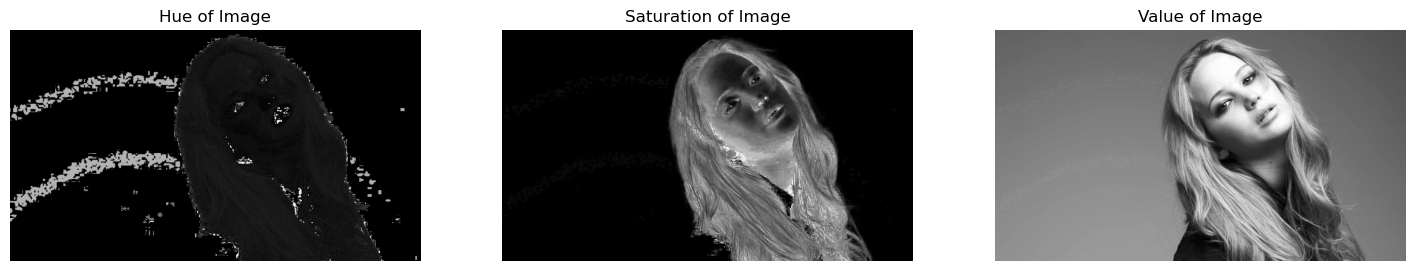

In [18]:
im6 = cv2.imread("Images/woman.jpeg")

im6_hsv = cv2.cvtColor(im6, cv2.COLOR_BGR2HSV)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(im6_hsv[:,:,0], cmap="grey")
axes[0].set_title("Hue of Image")
axes[0].axis("off")

axes[1].imshow(im6_hsv[:,:,1], cmap="grey")
axes[1].set_title("Saturation of Image")
axes[1].axis("off")


axes[2].imshow(im6_hsv[:,:,2], cmap="grey")
axes[2].set_title("Value of Image")
axes[2].axis("off")


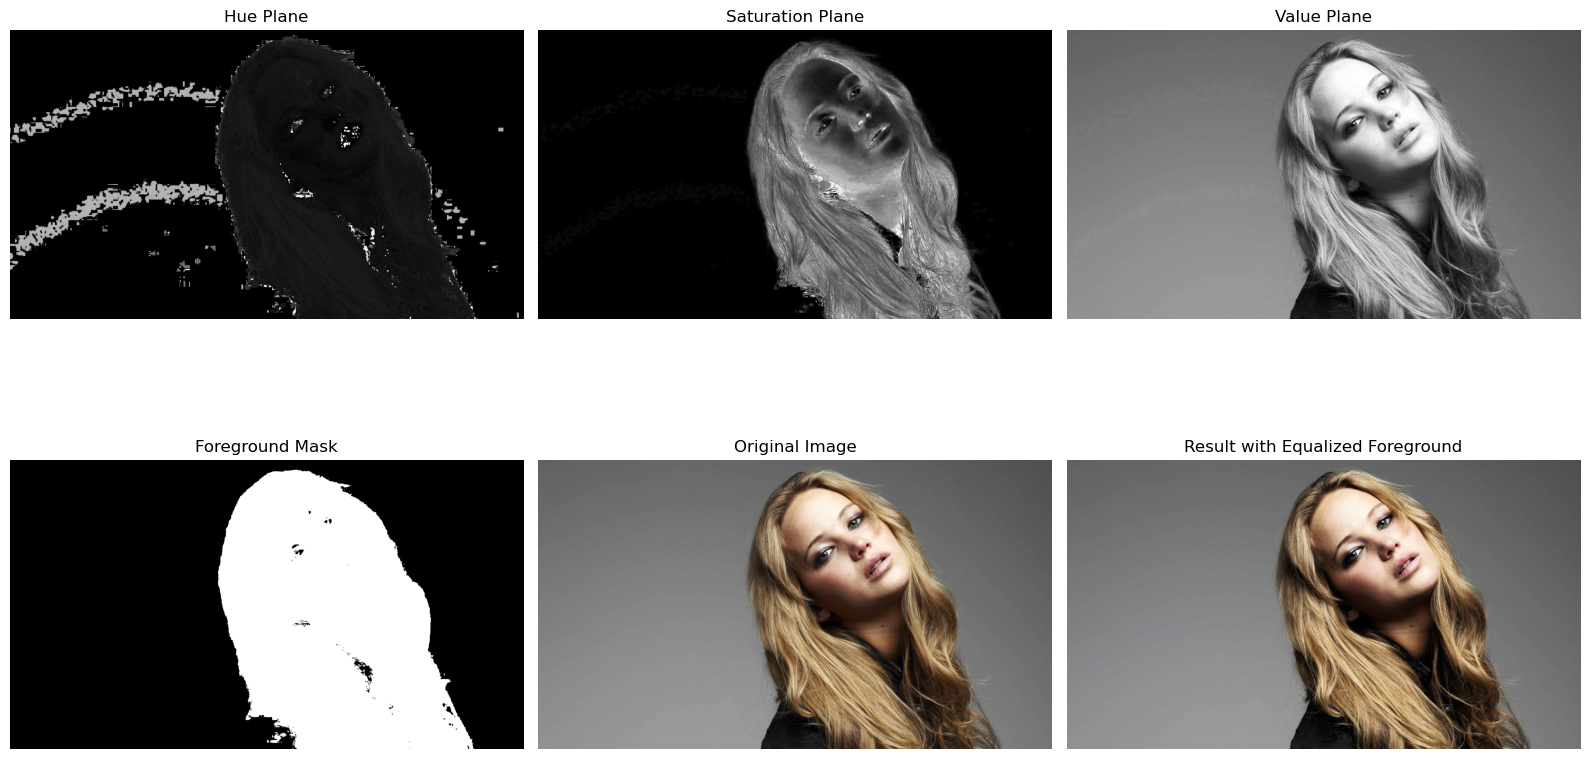

In [45]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

im6 = cv2.imread("Images/woman.jpeg")
assert im6 is not None

im6_rgb = cv2.cvtColor(im6, cv2.COLOR_BGR2RGB)
im6_hsv = cv2.cvtColor(im6, cv2.COLOR_BGR2HSV)
h_plane, s_plane, v_plane = cv2.split(im6_hsv)


_, mask = cv2.threshold(s_plane, 15, 255, cv2.THRESH_BINARY)
mask_inv = cv2.bitwise_not(mask)

hist_foreground = cv2.calcHist([v_plane], [0], mask, [256], [0, 256])

cumsum = np.cumsum(hist_foreground)
foreground_size = cumsum[-1]

L = 256
transform_map = np.array(((L - 1) / foreground_size) * cumsum).astype(np.uint8)

v_equalized = transform_map[v_plane]
v_foreground_new = cv2.bitwise_and(v_equalized, v_equalized, mask=mask)
v_background = cv2.bitwise_and(v_plane, v_plane, mask=mask_inv)

final_v = cv2.add(v_background, v_foreground_new)

final_hsv = cv2.merge([h_plane, s_plane, final_v])
final_rgb = cv2.cvtColor(final_hsv, cv2.COLOR_HSV2RGB)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes[0, 0].imshow(h_plane, cmap="gray")
axes[0, 0].set_title("Hue Plane")
axes[0, 0].axis("off")

axes[0, 1].imshow(s_plane, cmap="gray")
axes[0, 1].set_title("Saturation Plane")
axes[0, 1].axis("off")

axes[0, 2].imshow(v_plane, cmap="gray")
axes[0, 2].set_title("Value Plane")
axes[0, 2].axis("off")

axes[1, 0].imshow(mask, cmap="gray")
axes[1, 0].set_title("Foreground Mask")
axes[1, 0].axis("off")

axes[1, 1].imshow(im6_rgb)
axes[1, 1].set_title("Original Image")
axes[1, 1].axis("off")

axes[1, 2].imshow(final_rgb)
axes[1, 2].set_title("Result with Equalized Foreground")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

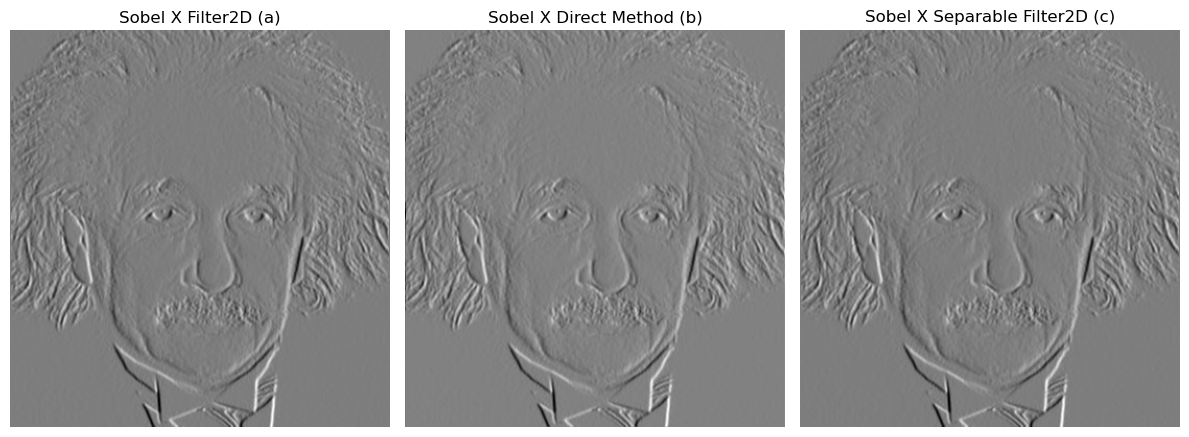

In [ ]:
im7 = cv2.imread("Images/einstein.jpeg", cv2.IMREAD_GRAYSCALE)
assert im7 is not None

sobel = np.array([[1,0,-1], [2, 0, -2], [1, 0, -1]], dtype=np.float32)

filtered1 = cv2.filter2D(im7, cv2.CV_32F, sobel)

[H, W] = np.shape(im7)

padded = np.pad(im7, pad_width=1, mode="constant", constant_values=0)

filtered = np.zeros((H, W), dtype=np.float32)

for i in range(H):
    for j in range(W):
        region = padded[i : i + 3, j : j + 3]
        filtered[i, j] = np.sum(region * sobel)

sobel2 = np.array([[1,0,-1]], dtype=np.float32)
sobel1 = np.array([[1], [2], [1]], dtype=np.float32)

filtered2 = cv2.filter2D(cv2.filter2D(im7, cv2.CV_32F, sobel1),cv2.CV_32F,sobel2)

fig, ax = plt.subplots(1, 3, figsize=(12, 8))

ax[0].imshow(filtered1, cmap='gray')
ax[0].set_title('Sobel X Filter2D (a)')
ax[0].axis("off")
ax[1].imshow(filtered, cmap='gray')
ax[1].set_title('Sobel X Direct Method (b)')
ax[1].axis("off")
ax[2].imshow(filtered2, cmap='gray')
ax[2].set_title('Sobel X Separable Filter2D (c)')
ax[2].axis("off")

plt.tight_layout()
plt.show()

In [76]:
im8_1_big = cv2.imread("Images/im01.png")
im8_2_big = cv2.imread("Images/im02.png")
im8_3_big = cv2.imread("Images/im03.png")
im8_4_big = cv2.imread("Images/im04.jpg")

im8_1_small = cv2.imread("Images/im01small.png")
im8_2_small = cv2.imread("Images/im02small.png")
im8_3_small = cv2.imread("Images/im03small.png")
im8_4_small = cv2.imread("Images/im04small.jpg")

def zoomNN(img, scale):
        return cv2.resize(img, None, fx=scale, fy=scale, interpolation=cv2.INTER_NEAREST)

def zoomBilinear(img, scale):
        return cv2.resize(img, None, fx=scale, fy=scale, interpolation=cv2.INTER_LINEAR)

def ssd(img1, img2):
    diff = img1.astype(np.float32) - img2.astype(np.float32)
    return np.mean(diff ** 2)

im8_1_zoomed_nn = zoomNN(im8_1_small, scale=4)
im8_1_zoomed_bilinear = zoomBilinear(im8_1_small, scale=4)

nn_SSD1 = ssd(im8_1_big, im8_1_zoomed_nn)
bilinear_SSD1 = ssd(im8_1_big, im8_1_zoomed_bilinear)

print('Normalized SSD for Nearest Neighbour of Image 1: ', nn_SSD1)
print('Normalized SSD for Bilinear of Image 1: ', bilinear_SSD1)

im8_2_zoomed_nn = zoomNN(im8_2_small, scale=4)
im8_2_zoomed_bilinear = zoomBilinear(im8_2_small, scale=4)

nn_SSD2 = ssd(im8_2_big, im8_2_zoomed_nn)
bilinear_SSD2 = ssd(im8_2_big, im8_2_zoomed_bilinear)

print('Normalized SSD for Nearest Neighbour of Image 2: ', nn_SSD2)
print('Normalized SSD for Bilinear of Image 2: ', bilinear_SSD2)

im8_3_zoomed_nn = zoomNN(im8_3_small, scale=4)
im8_3_zoomed_bilinear = zoomBilinear(im8_3_small, scale=4)

# %% Image 3 cannot be zoomed by the scaling factor 4 due to its size being indivisible by 4. #
# nn_SSD3 = ssd(im8_3_big, im8_3_zoomed_nn)
# bilinear_SSD3 = ssd(im8_3_big, im8_3_zoomed_bilinear)

# print('Normalized SSD for Nearest Neighbour of Image 3: ', nn_SSD3)
# print('Normalized SSD for Bilinear of Image 3: ', bilinear_SSD3)

im8_4_zoomed_nn = zoomNN(im8_4_small, scale=4)
im8_4_zoomed_bilinear = zoomBilinear(im8_4_small, scale=4)

nn_SSD4 = ssd(im8_4_big, im8_4_zoomed_nn)
bilinear_SSD4 = ssd(im8_4_big, im8_4_zoomed_bilinear)

print('Normalized SSD for Nearest Neighbour of Image 4: ', nn_SSD4)
print('Normalized SSD for Bilinear of Image 4: ', bilinear_SSD4)


Normalized SSD for Nearest Neighbour of Image 1:  136.26904
Normalized SSD for Bilinear of Image 1:  115.0919
Normalized SSD for Nearest Neighbour of Image 2:  26.446089
Normalized SSD for Bilinear of Image 2:  18.345919
Normalized SSD for Nearest Neighbour of Image 4:  228.62233
Normalized SSD for Bilinear of Image 4:  197.4095


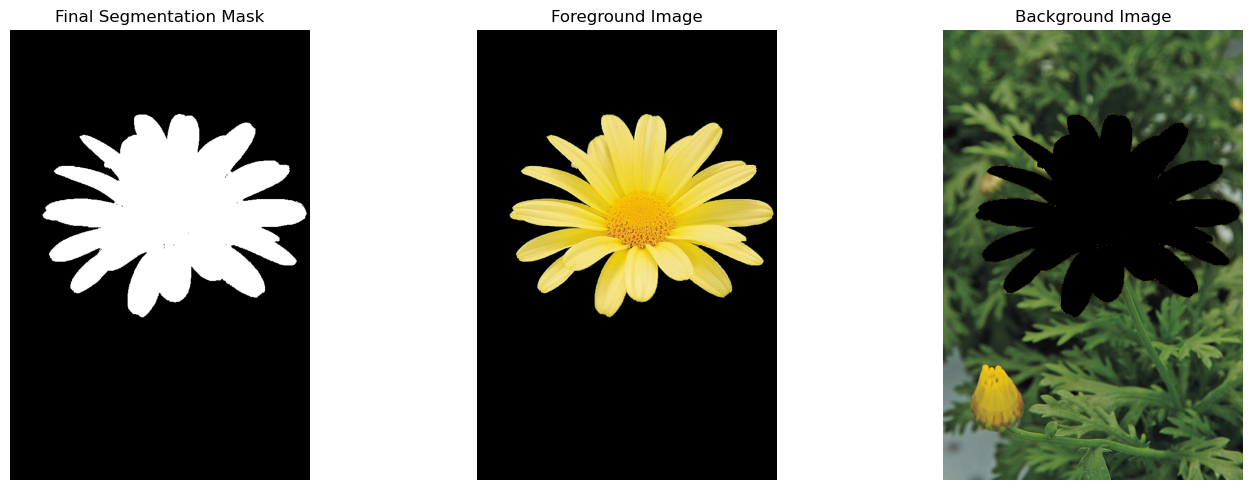

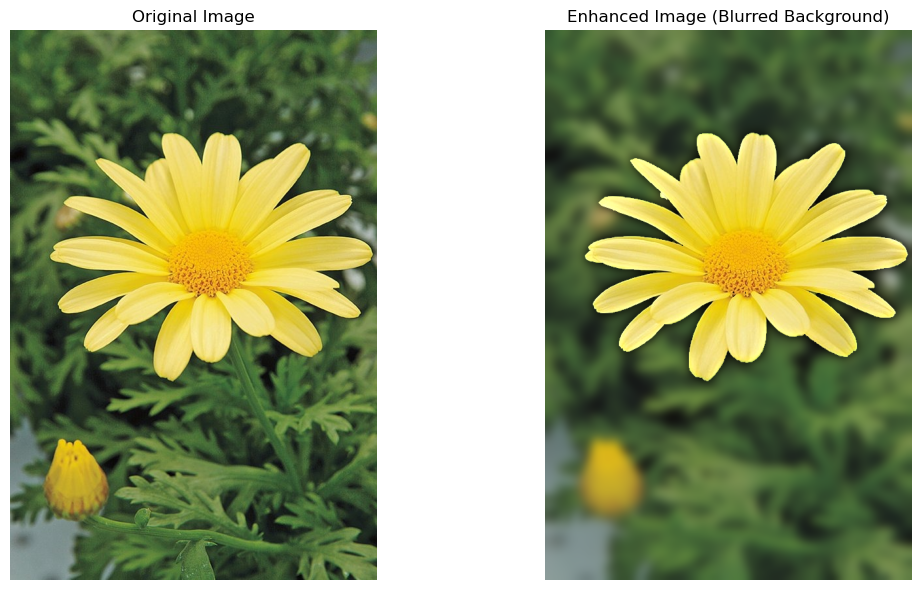

In [ ]:
im9 = cv2.imread("Images/flower.jpeg")
assert im9 is not None

im9_rgb = cv2.cvtColor(im9, cv2.COLOR_BGR2RGB)
H, W = im9.shape[:2]

mask = np.zeros((H, W), np.uint8)
bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)


# rect = (int(W * 0.1), int(H * 0.1), int(W * 0.8), int(H * 0.8))
rect = (10, 150, 550, 500)

cv2.grabCut(
    im9, mask, rect, bgdModel, fgdModel, iterCount=5, mode=cv2.GC_INIT_WITH_RECT
)


fg_mask = np.where((mask == cv2.GC_FGD) | (mask == cv2.GC_PR_FGD), 255, 0).astype(
    np.uint8
)
bg_mask = cv2.bitwise_not(fg_mask)

foreground = cv2.bitwise_and(im9_rgb, im9_rgb, mask=fg_mask)
background = cv2.bitwise_and(im9_rgb, im9_rgb, mask=bg_mask)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(fg_mask, cmap="gray")
axes[0].set_title("Final Segmentation Mask")
axes[0].axis("off")

axes[1].imshow(foreground)
axes[1].set_title("Foreground Image")
axes[1].axis("off")

axes[2].imshow(background)
axes[2].set_title("Background Image")
axes[2].axis("off")
plt.tight_layout()
plt.show()


blurred_bg = cv2.GaussianBlur(background, (51, 51), sigmaX=0)

enhanced_image = cv2.add(foreground, blurred_bg)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(im9_rgb)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(enhanced_image)
axes[1].set_title("Enhanced Image (Blurred Background)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

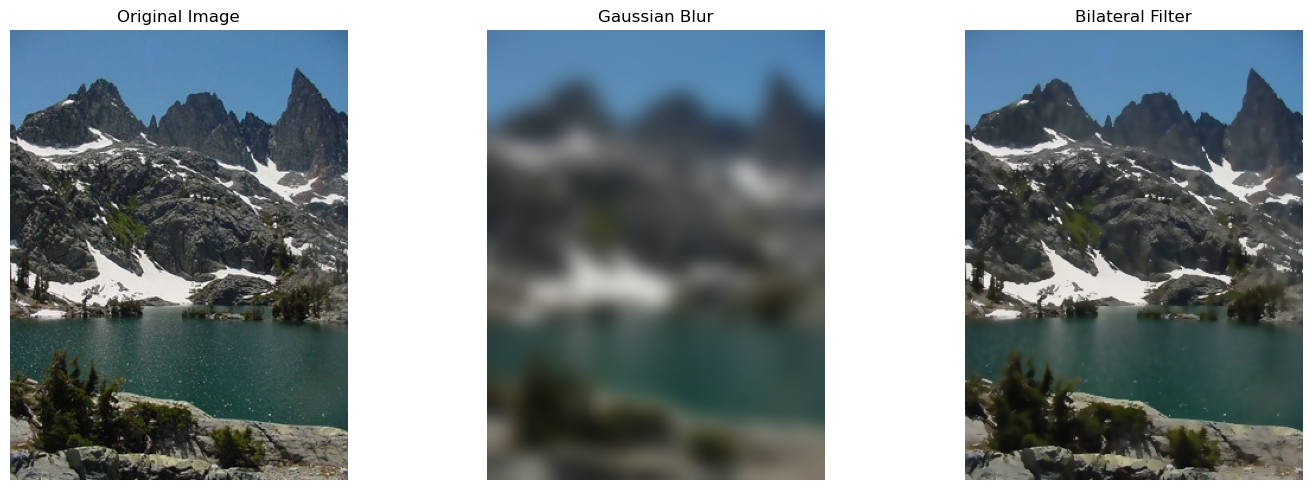

In [91]:
im10 = cv2.imread("Images/mountain.jpeg")
assert im10 is not None

im10_rgb = cv2.cvtColor(im10, cv2.COLOR_BGR2RGB)

standard_gaussian_blur = cv2.GaussianBlur(im10_rgb, (51, 51), sigmaX=0)

standard_bilateral_filter = cv2.bilateralFilter(im10_rgb, d=7, sigmaColor=75, sigmaSpace=75)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(im10_rgb, cmap="gray")
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(standard_gaussian_blur)
axes[1].set_title("Gaussian Blur")
axes[1].axis("off")

axes[2].imshow(standard_bilateral_filter)
axes[2].set_title("Bilateral Filter")
axes[2].axis("off")
plt.tight_layout()
plt.show()



In [92]:
def bilateral_filter_manual(image, radius, sigma_s, sigma_r):
    img = image.astype(np.float64)
    H, W = img.shape

    filtered = np.zeros((H, W), dtype=np.float64)

    for y in range(H):
        for x in range(W):
            I_x = img[y, x]
            weight_sum = 0.0
            pixel_acc = 0.0

            for dy in range(-radius, radius + 1):
                for dx in range(-radius, radius + 1):
                    yi = y + dy
                    xi = x + dx

                    if 0 <= yi < H and 0 <= xi < W:
                        I_xi = img[yi, xi]

                        spatial_dist_sq = dx * dx + dy * dy
                        g_s = math.exp(
                            -spatial_dist_sq / (2.0 * sigma_s * sigma_s)
                        )

                        range_dist_sq = (I_xi - I_x) ** 2
                        g_r = math.exp(
                            -range_dist_sq / (2.0 * sigma_r * sigma_r)
                        )

                        w = g_s * g_r
                        weight_sum += w
                        pixel_acc += w * I_xi

            filtered[y, x] = pixel_acc / weight_sum if weight_sum > 0 else I_x

    return np.clip(np.round(filtered), 0, 255).astype(np.uint8)

im10_r = im10_rgb[:, :, 0]
im10_r_bilateral = bilateral_filter_manual(im10_r, radius=7, sigma_s=75, sigma_r=75)

im10_g = im10_rgb[:, :, 1]
im10_g_bilateral = bilateral_filter_manual(im10_g, radius=7, sigma_s=75, sigma_r=75)

im10_b = im10_rgb[:, :, 2]
im10_b_bilateral = bilateral_filter_manual(im10_b, radius=7, sigma_s=75, sigma_r=75)

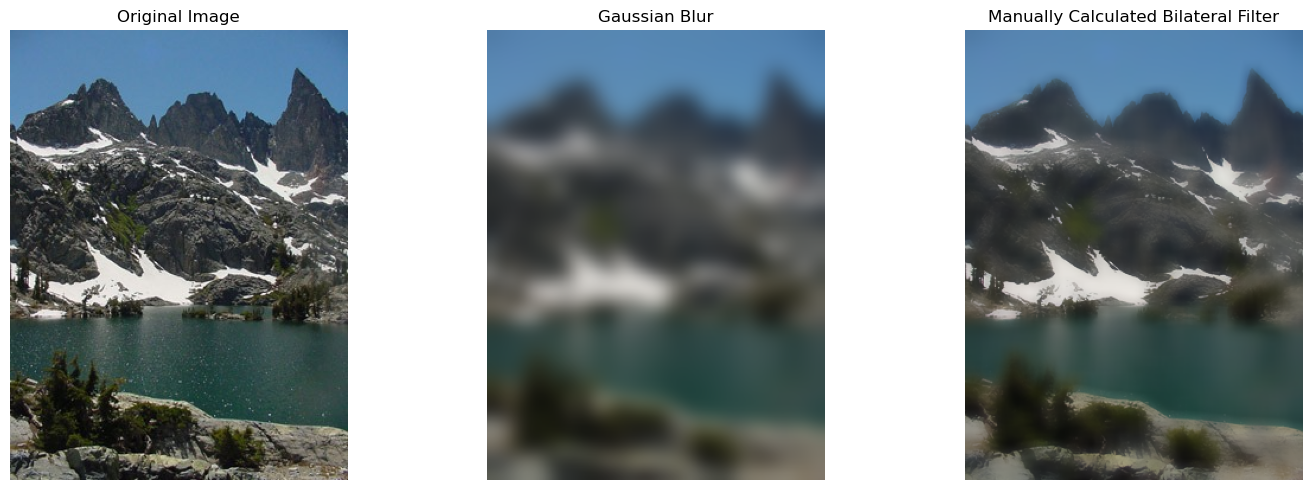

In [95]:
merged = cv2.merge([im10_r_bilateral, im10_g_bilateral, im10_b_bilateral])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(im10_rgb, cmap="gray")
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(standard_gaussian_blur)
axes[1].set_title("Gaussian Blur")
axes[1].axis("off")

axes[2].imshow(merged)
axes[2].set_title("Manually Calculated Bilateral Filter")
axes[2].axis("off")
plt.tight_layout()
plt.show()

In [97]:
#I am using the SSD function from before to compare between OpenCV2 bilateral filter and my manually calculated bilateral filter.

ssd_bilaterals = ssd(standard_bilateral_filter, merged)
print("Normalized SSD between OpenCV2 Bilateral Filter and Manually Calculated Bilateral Filter: ", ssd_bilaterals)

Normalized SSD between OpenCV2 Bilateral Filter and Manually Calculated Bilateral Filter:  201.461
